#Lab 1: Introduction to ScikitLearn and Classification Tasks

During this Lab, we aim to achieve the following:


*   Familiarize with <a href="https://scikit-learn.org/stable/"> scikit-learn </a>, an essential python library in data science;
*   learn how to approach a classification task with scikit-learn.

In this notebook, we learn to use Scikit-Learn with a practical example and then, in the second part, we will test our knowledge by doing some exercises.



# Part 1: A Classification Example With Scikit-Learn

We start our lab by implementing *Logistic Regression* using  scikit-learn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

[[ -4.89287606  -2.66252415]
 [  1.53513244 -17.71701488]
 [  2.5182605   -1.84224519]
 [  2.44773955   1.22644053]
 [  0.26080952 -10.3608732 ]
 [ -4.93419853 -11.87491308]
 [-11.14091064  -9.02493302]
 [ -3.84650002  -3.26967085]
 [  1.72390928   0.94676316]
 [  0.22019842  -3.97495822]
 [ -9.5434103   -9.29414049]
 [ -8.84586911  -2.47017747]
 [ -3.15198613  -3.10866018]
 [  8.04758892  -3.1059307 ]
 [  4.51512226  -5.69626898]
 [  1.48372716  -4.72320859]
 [ -1.24619567  -0.08046855]
 [ -2.59060124  -7.7649853 ]
 [  1.97108005   0.72102173]
 [ -4.10939125 -13.24348766]
 [  1.15603709  -9.46665443]
 [  4.52015465   1.10731538]
 [  0.73655564  -8.96913345]
 [  5.58087117   0.20618247]
 [  3.07191791  -2.64967086]
 [  1.49878533   1.77028153]
 [  1.76912283  -3.97549865]
 [ -5.72999469  -3.06430279]
 [ -1.48573418  -2.71616512]
 [  0.75656778 -14.52489211]
 [  0.39325343   4.78726736]
 [  4.3525562    1.26046682]
 [  5.17701727  -2.62601201]
 [ -8.54351608 -12.89055219]
 [  5.22743541

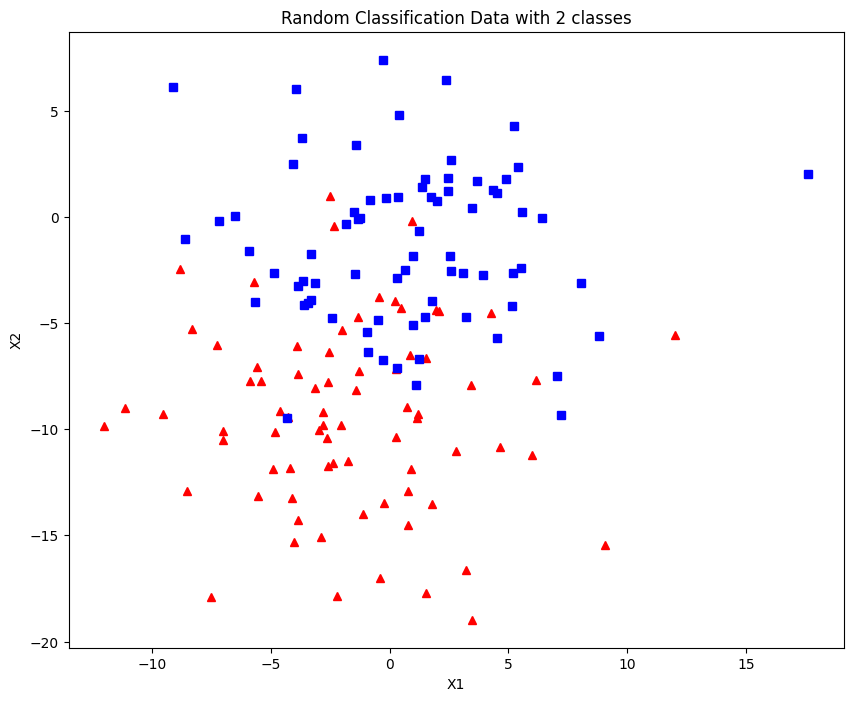

In [ ]:
from collections import Counter

X_toy, y_toy = datasets.make_blobs(n_samples=150,n_features=2,
                           centers=2,cluster_std=4.05,
                           random_state=2) # create an artificial dataset
print(X_toy)
print(y_toy)

print(Counter(y_toy))

#Plotting the data
fig = plt.figure(figsize=(10,8))
plt.plot(X_toy[:, 0][y_toy == 0], X_toy[:, 1][y_toy == 0], 'r^')
plt.plot(X_toy[:, 0][y_toy == 1], X_toy[:, 1][y_toy == 1], 'bs')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title('Random Classification Data with 2 classes')
plt.show()


We can now define our classifier: logistic regression <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"> [link] </a>.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression() # options for the classifiers are passed as parameters to constructor of the class
                              # LogisticRegression(). Either visit the link or put the cursor over it to see them


Sklearn defines standard functions for models, like *fit* and *predict*.

In [ ]:
#train phase
clf_lr.fit(X_toy, y_toy)


#estimation (y_hat)
y_pred_cl_lr = clf_lr.predict(X_toy)

print(y_pred_cl_lr)

[1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1
 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1
 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0
 1 1]


How to evaluate our models' performance? <br>
Scikit-learn offers a broad set of evaluation functions already implemented <a href = "https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics">[link]</a>.

In [ ]:
from sklearn.metrics import accuracy_score

print(f"Logistic Regression -- Toy dataset.\tACC: {accuracy_score(y_toy, y_pred_cl_lr)}")


Logistic Regression -- Toy dataset.	ACC: 0.8466666666666667


In [ ]:
# printing the values of the parameters after learning

print(clf_lr.coef_[0])


[0.13965618 0.50949503]


## Model Selection
When defining or training a model, we have the so called *hyperparameters*, i.e., different settings to configure for our training strategy.  <br>
The question is: *how can we decide the best configuration setting for the task?* <br>
The answer is the usage of *training* and *validation* partitions. <br>
We can use sklearn to do that: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_toy, y_toy,
                                                  train_size = 0.8, shuffle=False, random_state=42)

print(f"Original size = {X_toy.shape[0]}\tTrain size = {X_train.shape[0]}\tVal size = {X_val.shape[0]}")  # alternative way to use the print when there are
                                                                                                          # variables and text to print together


Original size = 150	Train size = 120	Val size = 30


First we use Scikit-Learn to train a <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html">Logistic Regression</a> classifier with default parameters over the Toy dataset. <br>
We compute the accuracy on both training and validation sets.


In [ ]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression()
clf_lr.fit(X_train, y_train)

#estimation (y_hat)
y_train_pred_lr = clf_lr.predict(X_train)
y_val_pred_lr = clf_lr.predict(X_val)

print(f"Logistic Regression.\tTrain ACC: {accuracy_score(y_train, y_train_pred_lr)}")
print(f"Logistic Regression.\tVal ACC: {accuracy_score(y_val, y_val_pred_lr)}")

Logistic Regression.	Train ACC: 0.8416666666666667
Logistic Regression.	Val ACC: 0.8666666666666667


### Model Selection with Logistic Regression

Logistic Regression has a hyperparameter *C*. Lower values of C correspond to simpler models (with the risk of underfitting), higher values of C correspond to complex models (with the risk of overfitting).  
Let's see how the performance change by varying it.

Let's find the best *C* among the following: $C = [0.001, 0.01, 0.1, 1., 10]$.

In [ ]:
C = [0.001, 0.01, 0.1, 1., 10, 100]
for c in C:
    clf_lr = LogisticRegression(C = c)
    clf_lr.fit(X_train, y_train)

    #estimation (y_hat)
    y_train_pred_lr = clf_lr.predict(X_train)
    y_val_pred_lr = clf_lr.predict(X_val)
    tr_acc = accuracy_score(y_train, y_train_pred_lr)
    val_acc= accuracy_score(y_val, y_val_pred_lr)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

LR. C= 0.001.	Train ACC: 0.8416666666666667	Val Acc: 0.9
LR. C= 0.01.	Train ACC: 0.8416666666666667	Val Acc: 0.9
LR. C= 0.1.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 1.0.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 10.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 100.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667


### Exercise: Model Selection with Logistic Regression


We ask you again to work on a classification task. <br>
This time, the classification is more challenging.
The dataset is called *sonar*.

In [ ]:
import pandas as pd
import random
random.seed(42)

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv'
ds = pd.read_csv(url, header = None)

# split into input and output elements
data = ds.values
random.shuffle(data)
X_sonar, y_sonar = data[:, :-1], data[:, -1]

print(X_sonar.shape, y_sonar.shape)


(208, 60) (208,)


It's time to partition our dataset. <br>
We ask you to create three partitions:


*   *train set* : a set of samples used to train a model.
*   *val set*: a set of samples used to decide the best model.
*   *test set*: a set of samples used to see our best model performance.

We now first split samples that we can use in our training (train and val), from samples that we cannot touch (test). <br>
**EX 1** Create a split between train_val and test, by maintaining the 25% of samples in the test set.

In [ ]:
#
# Ex 1: complete here
#
X_train_val, X_test, y_train_val, y_test = train_test_split(X_sonar, y_sonar,
                                                  train_size = 0.75, shuffle=False)

print(f"Original size = {X_sonar.shape[0]}\tTrain size = {X_train_val.shape[0]}\tTest size = {X_test.shape[0]}")

Original size = 208	Train size = 156	Test size = 52


**EX 1.2** From the train_val variables, split train and validation sets. Maintain the 10% of samples in the validation.


In [ ]:
#
# Ex 1.2: complete here
#
# X_train, X_val, y_train, y_val =

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                  train_size = 0.9, shuffle=False)

print(f"Original size = {X_train_val.shape[0]}\tTrain size = {X_train.shape[0]}\tValidation size = {X_val.shape[0]}")

print(X_train.shape, X_val.shape, X_test.shape)

Original size = 156	Train size = 140	Validation size = 16
(140, 60) (16, 60) (52, 60)


In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)

(140, 60) (16, 60) (52, 60)


**EX 2** Train and evaluate (using accuracy) a logistic regression with the default value for the hyperparameter. Do the evaluation **only** on the training and validation partitions.

In [ ]:
#
# Ex 2: complete here
#

from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()

#train phase
logmodel.fit(X_train, y_train)

#estimation (y_hat)
y_train_pred_logreg = logmodel.predict(X_train)
y_val_pred_logreg = logmodel.predict(X_val)

print(f"Logistic Regression -- Toy dataset.\tACC: {accuracy_score(y_train, y_train_pred_logreg)}")
print(f"Logistic Regression -- Toy dataset.\tACC: {accuracy_score(y_val, y_val_pred_logreg)}")

Logistic Regression -- Toy dataset.	ACC: 0.9428571428571428
Logistic Regression -- Toy dataset.	ACC: 0.8125


Let's find the best value for *C*, an hyperparameter of the model. <br>
See the documentation <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"> [link] </a>. <br>
**EX 3**  We ask you to find the best *C* among the following: $C = [0.001, 0.01, 0.1, 1., 10, 100, 1000, 10000]$.

In [ ]:
#
# Ex 3: complete here
#
C = [0.001, 0.01, 0.1, 1., 10, 100, 1000, 10000]

for c in C:
    logmodel = LogisticRegression(C = c)
    logmodel.fit(X_train, y_train)

    #estimation (y_hat)
    y_train_pred_logreg = logmodel.predict(X_train)
    y_val_pred_logreg = logmodel.predict(X_val)
    tr_acc = accuracy_score(y_train, y_train_pred_logreg)
    val_acc= accuracy_score(y_val, y_val_pred_logreg)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

LR. C= 0.001.	Train ACC: 0.9428571428571428	Val Acc: 0.8125
LR. C= 0.01.	Train ACC: 0.9428571428571428	Val Acc: 0.8125
LR. C= 0.1.	Train ACC: 0.9428571428571428	Val Acc: 0.8125
LR. C= 1.0.	Train ACC: 0.9428571428571428	Val Acc: 0.8125
LR. C= 10.	Train ACC: 0.9571428571428572	Val Acc: 0.8125
LR. C= 100.	Train ACC: 0.9928571428571429	Val Acc: 0.875
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.9375
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.9375


**Ex 4** It's time to see the performance on the test set of the best model, after training it on the training set. Use the accuracy as evaluation metric.

In [ ]:
#
# Ex 4: complete here
#

logmodel = LogisticRegression(C = c)
logmodel.fit(X_train, y_train)

#final estimation
y_test_pred = logmodel.predict(X_test)
print(accuracy_score(y_test, y_test_pred))

0.7115384615384616


## Computing Vectorial Representations

In [ ]:
!python -m spacy download "en_core_web_sm"
import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document or the forth?',
]
Y = [1, 0, 0, 1]


vectorizer = CountVectorizer()
vectorizer.fit(corpus)            # extracts the vocabulary from corpus (the list of unique words in corpus)
X = vectorizer.transform(corpus)  # build the bag of words representation of corpus with respect to the vocabulary computed with fit on the previous row

print(vectorizer.get_feature_names_out())
print("vocabulary size:", len(vectorizer.get_feature_names_out()))

# Let's see some of the options of CountVectorizer (first we change the tokenizer)
nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def spacy_tokenizer(text):
  return [token.text for token in nlp_en(text)]

vectorizer2 = CountVectorizer(binary=False, tokenizer=spacy_tokenizer)
X=vectorizer2.fit_transform(corpus)

print(vectorizer2.get_feature_names_out())
print("vocabulary size:", len(vectorizer2.get_feature_names_out()))

# now we can use X and Y in a learning algorithm


['and' 'document' 'first' 'forth' 'is' 'one' 'or' 'second' 'the' 'third'
 'this']
vocabulary size: 11
['.' '?' 'and' 'document' 'first' 'forth' 'is' 'one' 'or' 'second' 'the'
 'third' 'this']
vocabulary size: 13


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


#Sentiment Analysis

The dataset is described here: https://www.aclweb.org/anthology/P04-1035.pdf

It is part of nltk, so it is convenient for us to use.

The goal of this exercise is to build a first machine learning model using the tools that we have seen so far: choose how to preprocess the text, create a bag of words feature representation, train a model using an ML method of your choice.

You need to use the following split for the data:

*   test: 30% of the documents
*   The rest of the documents will be split as
    *   train: 75% of the documents
    *   validation: 25% of the documents

After splitting the data, turn the reviews into vectors, then apply a ML algorithm. Use accuracy as evaluation measure.

In [ ]:
import nltk
nltk.download('movie_reviews') # loads the dataset
nltk.download('punkt')
#!python -m spacy download "en_core_web_sm"


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Loading the data
In the following I extract the raw content of the reviews (movie_reviews.raw()), i.e. each review is a string.
Another option is to use movie_reviews.words() that returns each review as a list of tokens. Feel free to use whichever best fit your needs.


In [ ]:
from nltk.corpus import movie_reviews
import random
import spacy
from scipy.sparse import coo_matrix, vstack
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

documents = [(movie_reviews.raw(fileid), category)
              for category in movie_reviews.categories()
              for fileid in movie_reviews.fileids(category)]

print("number of docs loaded:", len(documents))

corpus_raw = [ x[0] for x in documents ]  # corpus_raw is a list of strings (reviews) to be converted into vectors
y_corpus = [ x[1] for x in documents ]    # y_corpus are the sentiment labels of the reviews (nothing to be done here)
print(corpus_raw[0])
print(y_corpus[0])

random.seed(42)


number of docs loaded: 2000
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an 

## Exercise - Lab. 1 Assignment

Create a vectorial representation of the data, then apply a learning algorithm by optimising the hyperparameters on the validation set. If you need to use any function that depends on random number generators, use 42 as seed.
Test several representations. You may try functions of the libraries we have seen in class or make your own vectorial representation from scratch.
Once you have selected the best hyperparameters and preprocessing, retrain your model on the union of the training and validation sets, then compute the accuracy on the test set.

Report your test performance on Moodle. In Moodle you are also supposed to upload the notebook in .py format (Menu File->Download->Download .py)
In the file with your code motivate any significant choice you made and all different preprocessing you attempted (clearly highlight the best one, though).

**Bonus Exercise** for your best model, print the 30 tokens whose corresponding parameter have highest absolute value. What do you think of this list? Does it make sense? Are all tokens expected?


In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#TOLENIZER FUNCTION
def spacy_tokenizer(text):
    return [token.text for token in npl_en(text)]

In [ ]:
#STEP 1 - SPLIT THE DATASET
X_train_val, X_test, y_train_val, y_test = train_test_split(corpus_raw, y_corpus,
                                                           train_size = 0.7, random_state=42, stratify=y_corpus)

# Split the resting set into 75% training and 25% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                           train_size = 0.75, random_state=42, stratify=y_train_val)

print("Class distribution in training set:", Counter(y_train))
# Print the sizes of the splits
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

#STEP 2 - PRE-PROCESS THE TRAINING SET: TOKENIZER + COUNTVECTORIZER
npl_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

#TOLENIZER FUNCTION - function executed on the top
#def spacy_tokenizer(text):
#    return [token.text for token in npl_en(text)]

#COUNTVECTORIZER
vectorizer = CountVectorizer(binary=False, tokenizer=spacy_tokenizer)

X_train_t = vectorizer.fit_transform(X_train)
X_val_t = vectorizer.transform(X_val)
X_test_t = vectorizer.transform(X_test)

#STEP 3 - TRAIN THE MODEL
best_C = None
best_val_acc = 0

C = [0.001, 0.01, 0.1, 1., 10, 100, 1000, 10000]
for c in C:
    logmodel = LogisticRegression(C = c, max_iter=1000)
    logmodel.fit(X_train_t, y_train)

    #STEP 4 - PREDICT AND EVALUATE THE MODEL

    y_train_pred = logmodel.predict(X_train_t)
    y_val_pred = logmodel.predict(X_val_t)
    tr_acc = accuracy_score(y_train, y_train_pred)
    val_acc= accuracy_score(y_val, y_val_pred)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

    #Update dynamically the best C
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C =c

print(f"The best C is: {best_C} with Accuracy: {best_val_acc}")

#STEP 5 - Apply to the final testing set

logmodel = LogisticRegression(C=best_C, max_iter=1000)
logmodel.fit(X_train_t, y_train)

#Predict on the test set
y_test_pred = logmodel.predict(X_test_t)

# Calculate and print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")


Class distribution in training set: Counter({'neg': 525, 'pos': 525})
Training set size: 1050
Validation set size: 350
Test set size: 600


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LR. C= 0.001.	Train ACC: 0.8885714285714286	Val Acc: 0.7514285714285714
LR. C= 0.01.	Train ACC: 0.9933333333333333	Val Acc: 0.8
LR. C= 0.1.	Train ACC: 1.0	Val Acc: 0.7971428571428572
LR. C= 1.0.	Train ACC: 1.0	Val Acc: 0.7971428571428572
LR. C= 10.	Train ACC: 1.0	Val Acc: 0.7942857142857143
LR. C= 100.	Train ACC: 1.0	Val Acc: 0.8085714285714286
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.7914285714285715
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.7885714285714286
The best C is: 100 with Accuracy: 0.8085714285714286
Test Accuracy: 0.8183333333333334


SECOND TRY - CHANGING THE C VALUES AND ADDING MORE. If the best C = 100, maybe we can find another better arround this value.

We will also add the parameters min_df=5 (ignores not repeated words), max_df=0.7 (Ignores words that appear in more than 70% of documents).

In [ ]:
#STEP 1 - SPLIT THE DATASET
X_train_val, X_test, y_train_val, y_test = train_test_split(corpus_raw, y_corpus,
                                                           train_size = 0.7, random_state=42, stratify=y_corpus)

# Split the resting set into 75% training and 25% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                           train_size = 0.75, random_state=42, stratify=y_train_val)

print("Class distribution in training set:", Counter(y_train))
# Print the sizes of the splits
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

#STEP 2 - PRE-PROCESS THE TRAINING SET: TOKENIZER + COUNTVECTORIZER
npl_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

#TOLENIZER FUNCTION - function executed on the top
#def spacy_tokenizer(text):
#    return [token.text for token in npl_en(text)]

#CountVectorizer -> We will add the parameters min_df and max_df
vectorizer = CountVectorizer(binary=False, tokenizer=spacy_tokenizer, min_df=5, max_df=0.8)

X_train_t = vectorizer.fit_transform(X_train)
X_val_t = vectorizer.transform(X_val)
X_test_t = vectorizer.transform(X_test)

#STEP 3 - TRAIN THE MODEL
best_C = None
best_val_acc = 0

C = [0.001, 0.01, 0.1, 1., 10, 50, 90, 100, 110, 300, 1000, 10000]
for c in C:
    logmodel = LogisticRegression(C = c, max_iter=1000)
    logmodel.fit(X_train_t, y_train)

    #STEP 4 - PREDICT AND EVALUATE THE MODEL

    y_train_pred = logmodel.predict(X_train_t)
    y_val_pred = logmodel.predict(X_val_t)
    tr_acc = accuracy_score(y_train, y_train_pred)
    val_acc= accuracy_score(y_val, y_val_pred)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

    #Update dynamically the best C
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C =c

print(f"The best C is: {best_C} with Accuracy: {best_val_acc}")

#STEP 5 - Apply to the final testing set

logmodel = LogisticRegression(C=best_C, max_iter=1000)
logmodel.fit(X_train_t, y_train)

#Predict on the test set
y_test_pred = logmodel.predict(X_test_t)

# Calculate and print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")


Class distribution in training set: Counter({'neg': 525, 'pos': 525})
Training set size: 1050
Validation set size: 350
Test set size: 600


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LR. C= 0.001.	Train ACC: 0.94	Val Acc: 0.78
LR. C= 0.01.	Train ACC: 0.9923809523809524	Val Acc: 0.8028571428571428
LR. C= 0.1.	Train ACC: 1.0	Val Acc: 0.8114285714285714
LR. C= 1.0.	Train ACC: 1.0	Val Acc: 0.8
LR. C= 10.	Train ACC: 1.0	Val Acc: 0.8
LR. C= 50.	Train ACC: 1.0	Val Acc: 0.8
LR. C= 90.	Train ACC: 1.0	Val Acc: 0.8057142857142857
LR. C= 100.	Train ACC: 1.0	Val Acc: 0.7942857142857143
LR. C= 110.	Train ACC: 1.0	Val Acc: 0.8
LR. C= 300.	Train ACC: 1.0	Val Acc: 0.7914285714285715
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.7914285714285715
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.7914285714285715
The best C is: 0.1 with Accuracy: 0.8114285714285714
Test Accuracy: 0.8266666666666667


3RD TRY - Now we will apply the Support Vector Machine model. This model is giving us the highest accuracy.

In [ ]:
from sklearn.svm import LinearSVC

#STEP 1 - SPLIT THE DATASET
X_train_val, X_test, y_train_val, y_test = train_test_split(corpus_raw, y_corpus,
                                                           train_size = 0.7, random_state=42, stratify=y_corpus)

# Split the resting set into 75% training and 25% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                           train_size = 0.75, random_state=42, stratify=y_train_val)

print("Class distribution in training set:", Counter(y_train))
# Print the sizes of the splits
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

#STEP 2 - PRE-PROCESS THE TRAINING SET: TOKENIZER + COUNTVECTORIZER
npl_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

#TOLENIZER FUNCTION - function executed on the top
#def spacy_tokenizer(text):
#    return [token.text for token in npl_en(text)]

#CountVectorizer -> We will add the parameters min_df and max_df
vectorizer = CountVectorizer(binary=False, tokenizer=spacy_tokenizer, min_df=5, max_df=0.7)

X_train_t = vectorizer.fit_transform(X_train)
X_val_t = vectorizer.transform(X_val)
X_test_t = vectorizer.transform(X_test)

#STEP 3 - TRAIN THE MODEL
best_C = None
best_val_acc = 0

C = [0.001, 0.01, 0.1, 1., 10, 50, 90, 100, 110, 300, 1000, 10000]
for c in C:
    model = LinearSVC(C=c, max_iter=1000)
    model.fit(X_train_t, y_train)

    #STEP 4 - PREDICT AND EVALUATE THE MODEL

    y_train_pred = model.predict(X_train_t)
    y_val_pred = model.predict(X_val_t)
    tr_acc = accuracy_score(y_train, y_train_pred)
    val_acc= accuracy_score(y_val, y_val_pred)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

    #Update dynamically the best C
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C =c

print(f"The best C is: {best_C} with Accuracy: {best_val_acc}")

#STEP 5 - Apply to the final testing set

model = LinearSVC(C=best_C, max_iter=1000)
model.fit(X_train_t, y_train)

#Predict on the test set
y_test_pred = model.predict(X_test_t)

# Calculate and print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")


Class distribution in training set: Counter({'neg': 525, 'pos': 525})
Training set size: 1050
Validation set size: 350
Test set size: 600


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LR. C= 0.001.	Train ACC: 0.9942857142857143	Val Acc: 0.8142857142857143
LR. C= 0.01.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 0.1.	Train ACC: 1.0	Val Acc: 0.7942857142857143
LR. C= 1.0.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 10.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 50.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 90.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 100.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 110.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 300.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.7857142857142857
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.7857142857142857
The best C is: 0.001 with Accuracy: 0.8142857142857143
Test Accuracy: 0.8316666666666667


4RTH TRY. Now we will apply the ngram_range=(1,2) in the SVM model.

In [ ]:
#STEP 1 - SPLIT THE DATASET
X_train_val, X_test, y_train_val, y_test = train_test_split(corpus_raw, y_corpus,
                                                           train_size = 0.7, random_state=42, stratify=y_corpus)

# Split the resting set into 75% training and 25% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                           train_size = 0.75, random_state=42, stratify=y_train_val)

print("Class distribution in training set:", Counter(y_train))
# Print the sizes of the splits
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

#STEP 2 - PRE-PROCESS THE TRAINING SET: TOKENIZER + COUNTVECTORIZER
npl_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

#TOLENIZER FUNCTION - function executed on the top
#def spacy_tokenizer(text):
#    return [token.text for token in npl_en(text)]

#CountVectorizer -> We will add the parameters min_df and max_df
vectorizer = CountVectorizer(ngram_range=(1,2), tokenizer=spacy_tokenizer, min_df=5, max_df=0.7)

X_train_t = vectorizer.fit_transform(X_train)
X_val_t = vectorizer.transform(X_val)
X_test_t = vectorizer.transform(X_test)

#STEP 3 - TRAIN THE MODEL
best_C = None
best_val_acc = 0

C = [0.001, 0.01, 0.1, 1., 10, 50, 90, 100, 110, 300, 1000, 10000]
for c in C:
    model = LinearSVC(C=c, max_iter=1000)
    model.fit(X_train_t, y_train)

    #STEP 4 - PREDICT AND EVALUATE THE MODEL

    y_train_pred = model.predict(X_train_t)
    y_val_pred = model.predict(X_val_t)
    tr_acc = accuracy_score(y_train, y_train_pred)
    val_acc= accuracy_score(y_val, y_val_pred)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

    #Update dynamically the best C
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C =c

print(f"The best C is: {best_C} with Accuracy: {best_val_acc}")

#STEP 5 - Apply to the final testing set

model = LinearSVC(C=best_C, max_iter=1000)
model.fit(X_train_t, y_train)

#Predict on the test set
y_test_pred = model.predict(X_test_t)

# Calculate and print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")


Class distribution in training set: Counter({'neg': 525, 'pos': 525})
Training set size: 1050
Validation set size: 350
Test set size: 600


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LR. C= 0.001.	Train ACC: 1.0	Val Acc: 0.84
LR. C= 0.01.	Train ACC: 1.0	Val Acc: 0.8257142857142857
LR. C= 0.1.	Train ACC: 1.0	Val Acc: 0.8257142857142857
LR. C= 1.0.	Train ACC: 1.0	Val Acc: 0.8257142857142857
LR. C= 10.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 50.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 90.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 100.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 110.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 300.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.8285714285714286
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.8285714285714286
The best C is: 0.001 with Accuracy: 0.84
Test Accuracy: 0.8416666666666667


In this 5th try we are introducing the parameter max_features in the CountVectorizer fuction. This is a way to help the model not having to much overfitting, but the result is that we have less Accuracy (0.8383 vs the 0.84167 of the 4rth try)

In [ ]:
#STEP 1 - SPLIT THE DATASET
X_train_val, X_test, y_train_val, y_test = train_test_split(corpus_raw, y_corpus,
                                                           train_size = 0.7, random_state=42, stratify=y_corpus)

# Split the resting set into 75% training and 25% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                           train_size = 0.75, random_state=42, stratify=y_train_val)

print("Class distribution in training set:", Counter(y_train))
# Print the sizes of the splits
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

#STEP 2 - PRE-PROCESS THE TRAINING SET: TOKENIZER + COUNTVECTORIZER
npl_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

#TOLENIZER FUNCTION - function executed on the top
#def spacy_tokenizer(text):
#    return [token.text for token in npl_en(text)]

#CountVectorizer -> We will add the parameters min_df and max_df
vectorizer = CountVectorizer(ngram_range=(1,2), tokenizer=spacy_tokenizer, min_df=5, max_df=0.7, max_features=5000)

X_train_t = vectorizer.fit_transform(X_train)
X_val_t = vectorizer.transform(X_val)
X_test_t = vectorizer.transform(X_test)

#STEP 3 - TRAIN THE MODEL
best_C = None
best_val_acc = 0

C = [0.001, 0.01, 0.1, 1., 10, 50, 90, 100, 110, 300, 1000, 10000]
for c in C:
    model = LinearSVC(C=c, max_iter=1000)
    model.fit(X_train_t, y_train)

    #STEP 4 - PREDICT AND EVALUATE THE MODEL

    y_train_pred = model.predict(X_train_t)
    y_val_pred = model.predict(X_val_t)
    tr_acc = accuracy_score(y_train, y_train_pred)
    val_acc= accuracy_score(y_val, y_val_pred)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

    #Update dynamically the best C
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C =c

print(f"The best C is: {best_C} with Accuracy: {best_val_acc}")

#STEP 5 - Apply to the final testing set

model = LinearSVC(C=best_C, max_iter=1000)
model.fit(X_train_t, y_train)

#Predict on the test set
y_test_pred = model.predict(X_test_t)

# Calculate and print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

Class distribution in training set: Counter({'neg': 525, 'pos': 525})
Training set size: 1050
Validation set size: 350
Test set size: 600


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


LR. C= 0.001.	Train ACC: 0.9990476190476191	Val Acc: 0.84
LR. C= 0.01.	Train ACC: 1.0	Val Acc: 0.8114285714285714
LR. C= 0.1.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 1.0.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 10.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 50.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 90.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 100.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 110.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 300.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 1000.	Train ACC: 1.0	Val Acc: 0.8028571428571428
LR. C= 10000.	Train ACC: 1.0	Val Acc: 0.8028571428571428
The best C is: 0.001 with Accuracy: 0.84
Test Accuracy: 0.8383333333333334


EXERCISE DEL PROFE

In [ ]:
from collections import Counter

def spacy_tokenizer(text):
  return [token.text for token in nlp_en(text)] # I tried these two, got no performance improvement
  #return [token.text + "_" + token.pos_ for token in nlp_en(text)]   # Add Part of Speech to tokens
  #return [token.text for token in nlp_en(text) if token.pos_=="ADJ"] # use only tokens related to adjectives

#feature_computer = CountVectorizer(binary=True, lowercase=False, tokenizer=spacy_tokenizer)

feature_computer = CountVectorizer(binary=True, lowercase=False)
#feature_computer = CountVectorizer(binary=True, lowercase=False, ngram_range=(1,2)) # try this!

print(Counter(y_corpus))  # the data is balanced, good!
print(y_corpus)           # attention! the first 1000 examples are all of class neg, the remaining ones are of class pos
                          # I need to shuffle the data (see shuffle=True next), otherwise the training set will basically
                          # only include neg examples, and the learning algorithm will hardly be effective

x_trainval, x_test, y_trainval, y_test = train_test_split(corpus_raw, y_corpus,
                                                    train_size = 0.70, shuffle=True, random_state = 42)

x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval,
                                                    train_size = 0.75, shuffle=True, random_state = 42)
print("training reviews:", len(y_train), "validation reviews:", len(y_val), "test reviews:", len(y_test))
train_features = feature_computer.fit_transform(x_train)
print("vocabulary size:", len(feature_computer.get_feature_names_out()))
val_features = feature_computer.transform(x_val)    # notice we don't do fit here, only transform, otherwise the validation
test_features = feature_computer.transform(x_test)  # and test sets would refer to different vocabularies and the resulting
                                                    # vectors would not be comparable

print(feature_computer.vocabulary_.items()) # print every token and its position in the vocabulary vector


In [ ]:
# we can perform learning now, since we have transformed the textual reviews into vectors

print("{0:>20} {1:>10}".format("C", "val acc"))

bestc = 0.0001
bestacc = 0.0

for c in [ 0.0001*10**x for x in range(9) ]:
  clf = LogisticRegression(random_state=42, C=c, max_iter=200).fit(train_features, y_train)
  curr_acc = accuracy_score(clf.predict(val_features), y_val)
  if curr_acc > bestacc:
    bestc = c
    bestacc = curr_acc
  print("{0:>20} {1:>10.3}".format(c, curr_acc))


trainval_features = feature_computer.fit_transform(x_trainval)  # recomputing the vectors on the union of train and validation sets
test_features = feature_computer.transform(x_test)              # so that I can train on train+validation

clf = LogisticRegression(C=bestc).fit(trainval_features, y_trainval)
print("\naccuracy on the test set for c=", bestc, ":", accuracy_score(clf.predict(test_features), y_test))


I have try 5 different models in the Sentiment Analysis part. The 1st try is giving us an accuracy higher than 0,8.

In the second try, I wanted to try some different C values and so I added some more. If the best C = 100, maybe we can find another better around this value. Unluckily, the best C continuous to be the C=100.

We will also add the parameters min_df=5 (ignores not repeated words), max_df=0.7 (Ignores words that appear in more than 70% of documents)

In the 3rd try I will change the model to the Support Vector Machine model. This model is giving us a higher accuracy than applying the Logistic Regression model.

In the 4th try I have apply the ngram_range=(1,2) parameter in the CountVectorizer fuction with the the SVM model.

In this 5th try I have introduced the parameter max_features in the CountVectorizer fuction. This is a way to help the model not having to much overfitting, but the result is that we have less Accuracy (0.8383 vs the 0.84167 of the 4rth try)

BONUS EXERCISE

In [ ]:
print("Feature_names:", vectorizer.get_feature_names_out())
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Shape of X_test_t:", X_test_t.shape)

Feature_names: ['\n ' '\n  "' '\n  (' ... 'yourself' 'youth' 'zero']
Vocabulary size: 5000
Shape of X_test_t: (600, 5000)


In [ ]:
feature_names = vectorizer.get_feature_names_out()
coef  = model.coef_[0]
feature_coef  = list(zip(feature_names, coef))
sorted_features  = sorted(feature_coef, key=lambda x: abs(x[1]), reverse=True)

# Print the 30 tokens whose corresponding parameter have highest absolute value
for feature, coefficient in sorted_features[:50]:
    print(f"Token: {feature}, Coefficient: {coef}")


Token: bad, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: well, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: with a, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: could, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: plot, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: should, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: looks, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: joan, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: only, Coefficient: [-0.01735361 -0.01555854 -0.04294355 ...  0.01101954 -0.0115013
  0.00037332]
Token: hilarious, Coefficient: [-0.01735361 -0.01555854 -0.

In [ ]:
model_weights = [ (clf.coef_[0][feature_value], feature_name) for feature_name, feature_value in feature_computer.vocabulary_.items() ]
# model_weights is a list of pairs of values: (weight of the parameter theta_i of Logistic Regression, corresponding token)

for v,f in sorted(model_weights, key=lambda x: abs(x[0]), reverse=True)[:30]: # sorting the tokens with respect to the absolute value of the parameter weight (which represents the importance of that token)
  print("{0:>30} = {1:7.6}".format(f,v))
# if the weight of a parameter is negative, the token correlates with one class (neg in this case), if it is positive with the other (pos)
# most of the tokens are are adjectives, which makes sense
